Testing the script which converts from N to t and I also want to compare the resulting $\phi$ curved from integration in cosmic time and efolds

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [15]:
path = "../SAVED_HERE/phi_k200_b1.2.csv"

with open(path, "r") as f:
    params = f.readline()
    header = f.readline()
    lines = f.readlines()

print(f"PARAMS: {params}")
print(f"HEADER: {header}")

n = len(lines)

N_arr = np.empty(n)
phi_arr = np.empty(n)
phi_prime_arr = np.empty(n)

for i, line in enumerate(lines):
    row = line.strip().split(",")

    N_arr[i] = float(row[0])
    phi_arr[i] = float(row[1])
    phi_prime_arr[i] = float(row[2])

    print(f"N: {N_arr}")
    print(f"phi: {phi_arr}")
    print(f"phi_prime: {phi_prime_arr}")

PARAMS: # params: {'kappa': 200, 'alpha': 1.5, 'b': 1.2, 'phi_sbp': 0.1, 'N_end': 20.0}

HEADER: N,phi,phi_prime

N: [0.00000000e+000 6.15525340e-310 4.02751406e-315 ... 6.15518574e-310
 6.15518574e-310 6.15518574e-310]
phi: [-9.56514913e+000  6.15525340e-310  4.02751406e-315 ...  2.29380000e+001
  2.29390000e+001  2.29400000e+001]
phi_prime: [ 5.75580200e-002  6.15525340e-310  4.02751406e-315 ... -1.60440053e+000
 -1.60195104e+000 -1.59950155e+000]
N: [0.00000000e+000 1.00000000e-003 4.02751406e-315 ... 6.15518574e-310
 6.15518574e-310 6.15518574e-310]
phi: [-9.56514913e+000 -9.56509157e+000  4.02751406e-315 ...  2.29380000e+001
  2.29390000e+001  2.29400000e+001]
phi_prime: [ 5.75580200e-002  5.75580242e-002  4.02751406e-315 ... -1.60440053e+000
 -1.60195104e+000 -1.59950155e+000]
N: [0.00000000e+000 1.00000000e-003 2.00000000e-003 ... 6.15518574e-310
 6.15518574e-310 6.15518574e-310]
phi: [-9.56514913 -9.56509157 -9.56503401 ... 22.938      22.939
 22.94      ]
phi_prime: [ 0.057558

In [16]:
V0 = 1e-12
kappa = 200
b = 1.2

In [17]:
t_arr = np.zeros(n)
H_arr = np.empty(n)

def V(phi):
    return V0 * np.exp(- kappa * np.exp(phi/b))

H_arr = np.sqrt(V(phi_arr)/(3-0.5 * phi_prime_arr**2))

integrand = 1.0 / H_arr

t_arr[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * np.diff(N_arr))

print(f"time: {t_arr}")

time: [0.00000000e+00 1.79241815e+03 3.58483927e+03 ... 1.03231998e+43
 1.28535068e+43 1.60112534e+43]


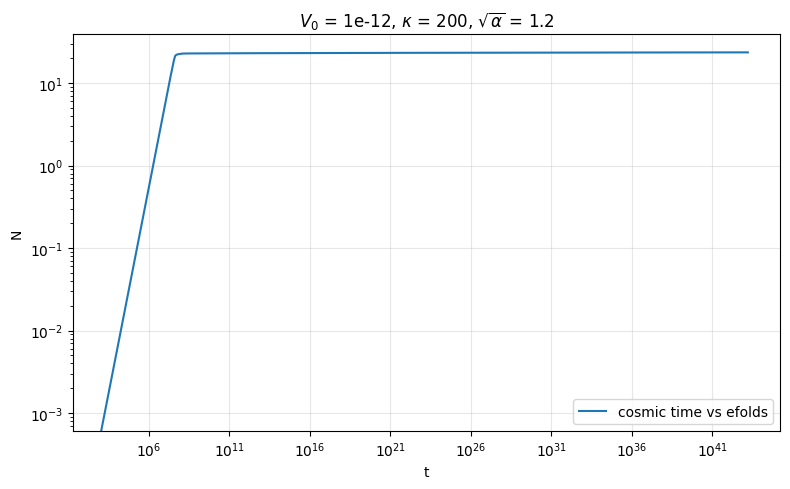

In [18]:
plt.figure(figsize=(8,5))

title = rf"$V_0$ = {V0}, $\kappa$ = {kappa}, $\sqrt {{\alpha}}$ = {b}"

plt.plot(t_arr, N_arr, label="cosmic time vs efolds")
plt.xscale("log")
plt.yscale("log")
plt.title(title)
plt.xlabel("t")
plt.ylabel("N")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

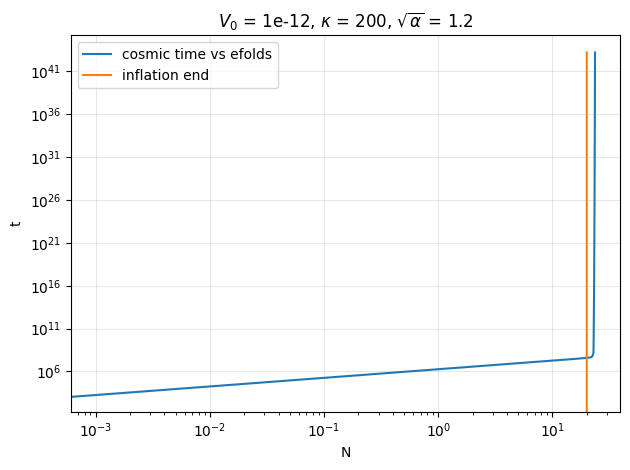

In [22]:
plt.plot(N_arr, t_arr, label="cosmic time vs efolds")
const_arr = np.ones(n) * 20.0
plt.plot(const_arr, t_arr, label="inflation end")

plt.xscale("log")
plt.yscale("log")
plt.title(fr"$V_0$ = {V0}, $\kappa$ = {kappa}, $\sqrt{{\alpha}}$ = {b}")
plt.xlabel("N")
plt.ylabel("t")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

checking intersection

In [20]:
diff = N_arr - const_arr
idx = np.where(np.sign(diff[1:]) != np.sign(diff[:-1]))[0]
id = idx[0]
print(f"idx: {id}")
print(f"Intersection at t = {t_arr[id]}, N = {N_arr[id]}, const = {const_arr[id]}")


idx: 19999
Intersection at t = 38201377.34017711, N = 19.99900000000146, const = 20.0


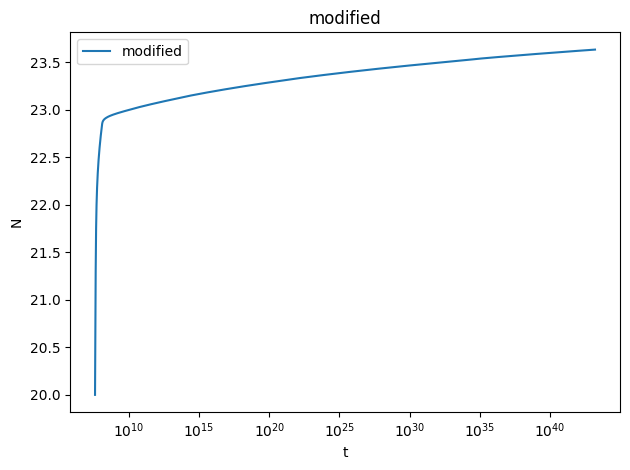

In [21]:
# id += 1000
N_mod_arr = N_arr[id:]
t_mod_arr = t_arr[id:]

plt.plot(t_mod_arr, N_mod_arr, label="modified")
plt.xlabel("t")
plt.xscale("log")
plt.ylabel("N")
plt.title("modified")
plt.legend()
plt.tight_layout()
plt.show()